# Deep Learning Project: Predicting if a bank customer will exit the bank

## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

import wandb
from wandb.integration.keras import WandbMetricsLogger

from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## set up wandb

In [3]:
!pip install wandb -q

In [4]:
wandb.login()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: arminfakhar1384 (arminfakhar1384-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Importing the dataset

In [5]:
dataset = pd.read_csv("Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

#print(X)
#print(Y)

## Data preprocessing

### Splitting the data into train & test

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [7]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography & gender column

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [9]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Building the Nerual Network

#### A feedforward neural network is constructed with:


*   An input layer that receives the preprocessed feature vectors.
*   Two fully connected hidden layers (64 and 32 neurons) using the ReLU activation function.


*   One output layer with a single neuron using the Sigmoid activation function for binary classification.

#### The ReLU activation function is used in the hidden layers to introduce non-linearity and enable the network to learn complex patterns from the data. The Sigmoid activation function is applied in the output layer to produce probability values between 0 and 1, making it suitable for predicting binary outcomes.






### Initializing the ANN

In [10]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [11]:
tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Dense name=dense, built=False>

### Adding the second hidden layer

In [12]:
model.add(tf.keras.layers.Dense(units=32, activation='relu'))

### Adding the output layer

In [13]:
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

### Compiling the ANN

#### The model is compiled using:


*   Adam optimizer with learning rate 0.001 for efficient gradient updates.
*   Binary Crossentropy loss, suitable for binary classification tasks.
*   Evaluation metrics including Accuracy, Precision, Recall, and AUC to comprehensively assess performance.



In [14]:
tf.keras.backend.clear_session()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

## Training the ANN on the Training set

### Callbacks - Saving checkpoint

In [15]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Experiment Tracking Configuration (WandB)

In [16]:
RUN_NAME = "model_1_baseline"

wandb.init(
    project="bank_customers_churn",
    name=RUN_NAME,
    config={
        "model_id": 1,
        "architecture": "64-32-relu + sigmoid",
        "epochs": 50,
        "batch_size": 128,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "loss": "binary_crossentropy"
    }
)

wandb_callback = WandbMetricsLogger()

### Train the model

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[checkpoint, wandb_callback]
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.4282 - auc: 0.5387 - loss: 0.7652 - precision: 0.2178 - recall: 0.6677 - val_accuracy: 0.7519 - val_auc: 0.5805 - val_loss: 0.5741 - val_precision: 0.3046 - val_recall: 0.1875
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7680 - auc: 0.6048 - loss: 0.5502 - precision: 0.3572 - recall: 0.1300 - val_accuracy: 0.8037 - val_auc: 0.6623 - val_loss: 0.4890 - val_precision: 0.5789 - val_recall: 0.0688
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8071 - auc: 0.6867 - loss: 0.4775 - precision: 0.6977 - recall: 0.0716 - val_accuracy: 0.8075 - val_auc: 0.7025 - val_loss: 0.4605 - val_precision: 0.6364 - val_recall: 0.0875
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8053 - auc: 0.7193 - loss: 0.4631 - precision: 0.7305 - recall: 0.1124 - val_accuracy: 0.8125 - val_auc: 0.7221 - val_loss: 0.4473 - val_precision: 0.6724 - val_recall: 0.1219
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━

### Performance Visualization - Training and Validation Curves

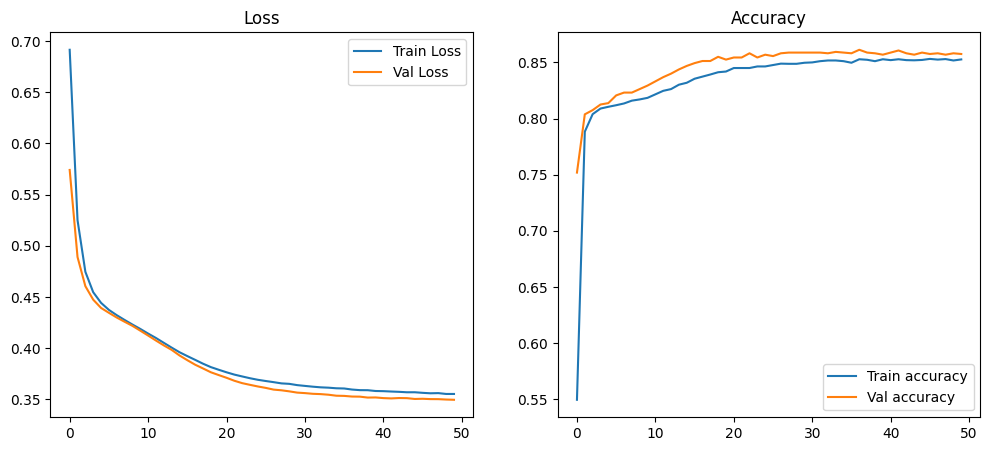

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.legend()
plt.title("Accuracy")

plt.show()

#### The training and validation loss decrease rapidly in the initial epochs and then gradually converge to approximately 0.35, indicating stable and consistent learning behavior. The validation loss remains slightly lower than the training loss throughout training, and the small gap between the curves suggests good generalization without signs of overfitting.

#### Accuracy increases sharply at the beginning and stabilizes around 85–86% for both training and validation sets. The validation accuracy is consistently slightly higher than the training accuracy, and the close alignment of the curves reflects stable and reliable performance of the baseline model.

### Hyperparameters table

In [19]:
import pandas as pd

hyperparameters = {
    "Parameter": [
        "Model ID",
        "Hidden Layer 1 Units",
        "Hidden Layer 2 Units",
        "Activation Function (Hidden)",
        "Output Activation",
        "Optimizer",
        "Learning Rate",
        "Loss Function",
        "Batch Size",
        "Epochs"
    ],
    "Value": [
        "Model 1 (Baseline)",
        64,
        32,
        "ReLU",
        "Sigmoid",
        "Adam",
        0.001,
        "Binary Crossentropy",
        128,
        50
    ]
}

hp_table = pd.DataFrame(hyperparameters)
hp_table


,Parameter,Value
0,Model ID,Model 1 (Baseline)
1,Hidden Layer 1 Units,64
2,Hidden Layer 2 Units,32
3,Activation Function (Hidden),ReLU
4,Output Activation,Sigmoid
5,Optimizer,Adam
6,Learning Rate,0.001
7,Loss Function,Binary Crossentropy
8,Batch Size,128
9,Epochs,50


## Predicting and evaluating the model


### Confusion Matrix Analysis

In [20]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
 [[1540   53]
 [ 246  161]]


#### This means:


*   True Negatives (TN): 1540
*   False Positives (FP): 53
*   False Negatives (FN): 246
*   True Positives (TP): 161
#### The model performs very well in identifying the majority class (Class 0), but it struggles to correctly detect the minority class (Class 1).





### Performance metrics

In [21]:
results = model.evaluate(X_test, y_test, verbose=0)
print("Test Results (loss, acc, precision, recall, auc):\n", results)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

Test Results (loss, acc, precision, recall, auc):
 [0.3578605055809021, 0.8504999876022339, 0.7523364424705505, 0.39557740092277527, 0.8434712886810303]

Classification Report:

              precision    recall  f1-score   support

           0     0.8623    0.9667    0.9115      1593
           1     0.7523    0.3956    0.5185       407

    accuracy                         0.8505      2000
   macro avg     0.8073    0.6812    0.7150      2000
weighted avg     0.8399    0.8505    0.8315      2000

ROC-AUC: 0.8434335722471314


### Plotting ROC Curve

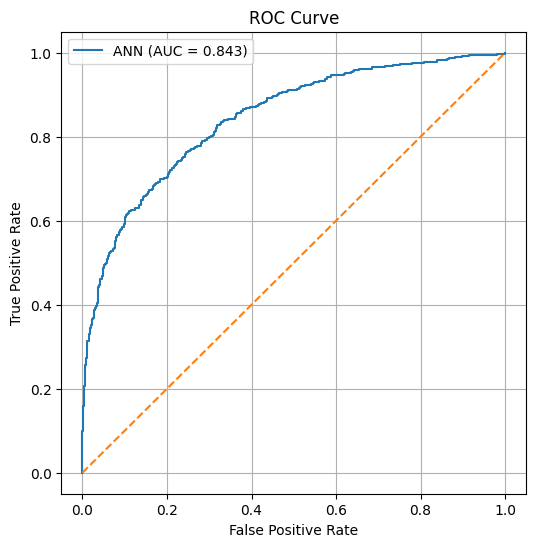

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Results Analysis


#### Model 1 shows stable training behavior, with training and validation loss decreasing smoothly and converging around 0.35. Accuracy stabilizes at approximately 85%, and the ROC-AUC score of 0.843 indicates good overall class separability. The model performs particularly well in identifying the majority class, with a high number of true negatives and a low number of false positives.

#### However, the dataset is imbalanced (1593 samples in Class 0 vs. 407 in Class 1), which causes the model to favor the majority class. This results in low recall for the positive class (39.6%) and a high number of false negatives.

#### To address this issue, future improvements may include applying class weights, resampling techniques, threshold adjustment, or alternative loss functions to better handle class imbalance.